# Transposed Convolution
Also called:
- Deconvolution (loose, and slightly misleading — it is *not* an inverse of convolution)
- Upconvolution
- Fractionally strided convolution


### Scatter view

<p align="center">
  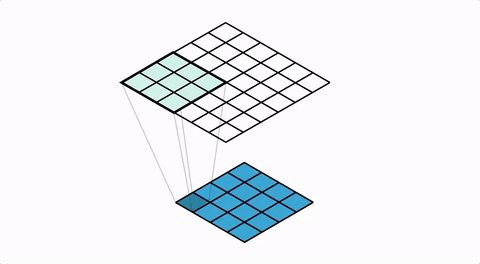
</p>

Here a **4×4 input** (blue) produces a **6×6 output** (green) with a 3×3 kernel, stride 1, no padding. Each input pixel deposits a *scaled copy of the whole kernel* into the output, and overlapping copies are **summed** — this is the **scatter / overlap-add** picture, matching the *Scatter view* in the definition below. No zeros are drawn: the growth in size comes purely from the kernel footprint extending past the input border.

The **gather** view — the *equivalent ordinary convolution* derived below under **Equivalent form** — draws the **same operation** the other way: the input is surrounded by (dashed) zeros and a kernel slides to gather each output value. Both compute the identical result; its animations appear there.


## Definition: Infinite 2D Transposed Convolution

Transposed convolution (often loosely called *deconvolution*) is **not** an inverse of convolution; it is the operation that **spreads** each input element over the output grid, following the same connectivity as a convolution but in the opposite direction.

Input  
* $X \in \mathbb{R}^{C_1\times \mathbb{Z}^2}.$  

Weights  
* kernel $W \in \mathbb{R}^{C_1\times C_2 \times h \times w}$ (note the **transposed** channel order $C_1\times C_2$)  
* bias $b \in \mathbb{R}^{C_2}$  

Hyperparameters  
* stride $s=(s_1,s_2)$  

Output  
* $\operatorname{InfConvT2d}_{W,b}(X) = O \in \mathbb{R}^{C_2\times \mathbb{Z}^2}$.

**Scatter view.** Every input site $(l,j,k)$ deposits a scaled copy of the kernel into the output:
$$
x_{l,j,k}\ \longmapsto\ x_{l,j,k}\,\omega_{l,i,m,n}\ \text{ added to }\ O_{i,\,(j-1)s_1+m,\,(k-1)s_2+n},\qquad 1\le m\le h,\ 1\le n\le w.
$$

**Gather view.** Collecting all contributions that land on a fixed output site $(i,u,v)$ yields the closed form
$$
\begin{align*}
O_{i,u,v} &= b_{i} + \sum_{l=1}^{C_1} \sum_{m=1}^{h} \sum_{n=1}^{w}
\mathbb{1}\!\left[s_1 \mid u-m\right]\,\mathbb{1}\!\left[s_2 \mid v-n\right]\;
x_{l,\,\frac{u-m}{s_1}+1,\,\frac{v-n}{s_2}+1}\;
\omega_{l,i,m,n}.
\end{align*}
$$

Contrast this with $\operatorname{InfConv2d}$, whose output *gathers* a fixed window of inputs. Here the roles are reversed: each input *scatters*, and the indicators $\mathbb{1}[s\mid\cdot]$ encode the zeros that a stride $s>1$ inserts between deposited kernels.


### Property: $\operatorname{InfConvT2d}_{W,0}$ is linear and $\operatorname{InfConvT2d}_{W,b}$ is affine


Proof: Fix an output site $(i,u,v)$ and abbreviate $\chi(m,n) = \mathbb{1}[s_1\mid u-m]\,\mathbb{1}[s_2\mid v-n]$ and $\pi(m,n)=\left(\tfrac{u-m}{s_1}+1,\tfrac{v-n}{s_2}+1\right)$. For $\alpha,\beta\in\mathbb{R}$ and $X,Y\in\mathbb{R}^{C_1\times\mathbb{Z}^2}$,
$$
\begin{align*}
\operatorname{InfConvT2d}_{W,0}(\alpha X+\beta Y)_{i,u,v}
&=\sum_{l=1}^{C_1}\sum_{m=1}^{h}\sum_{n=1}^{w}\chi(m,n)\,\big(\alpha x_{l,\pi(m,n)}+\beta y_{l,\pi(m,n)}\big)\,\omega_{l,i,m,n},\\
&=\alpha\sum_{l,m,n}\chi(m,n)\,x_{l,\pi(m,n)}\,\omega_{l,i,m,n}+\beta\sum_{l,m,n}\chi(m,n)\,y_{l,\pi(m,n)}\,\omega_{l,i,m,n},\\
&=\alpha\,\operatorname{InfConvT2d}_{W,0}(X)_{i,u,v}+\beta\,\operatorname{InfConvT2d}_{W,0}(Y)_{i,u,v}.
\end{align*}
$$
Hence $\operatorname{InfConvT2d}_{W,0}$ is linear. Since $\operatorname{InfConvT2d}_{W,b}=\operatorname{InfConvT2d}_{W,0}+b$ adds the constant tensor $b$ (broadcast over $\mathbb{Z}^2$), $\operatorname{InfConvT2d}_{W,b}$ is affine.


### Property: $\operatorname{InfConvT2d}_{W,b}$ is translation-equivariant up to stride

Recall the positional translation $T^{C}_{\delta}$ with $T^{C}_{\delta}(X)_{i,j,k}=X_{i,j+\delta_1,k+\delta_2}$.

Whereas convolution *contracts* a translation by the stride, transposed convolution *dilates* it: a shift of the input by $\delta$ produces a shift of the output by $s*\delta$,
$$
\operatorname{InfConvT2d}_{W,b}\circ\,T^{C_1}_{\delta} = T^{C_2}_{s*\delta}\circ \operatorname{InfConvT2d}_{W,b}, \qquad \forall \delta\in\mathbb{Z}^2.
$$
For stride $s=(1,1)$ this is **full translation equivariance**.


Proof: Fix an output site $(i,u,v)$ and abbreviate $\chi(m,n)=\mathbb{1}[s_1\mid u-m]\,\mathbb{1}[s_2\mid v-n]$,
$$
\begin{align*}
\operatorname{InfConvT2d}_{W,b}(T^{C_1}_{\delta}(X))_{i,u,v}
&=b_i+\sum_{l,m,n}\chi(m,n)\,T^{C_1}_{\delta}(X)_{l,\frac{u-m}{s_1}+1,\frac{v-n}{s_2}+1}\,\omega_{l,i,m,n},\\
&=b_i+\sum_{l,m,n}\chi(m,n)\,x_{l,\frac{u-m}{s_1}+1+\delta_1,\frac{v-n}{s_2}+1+\delta_2}\,\omega_{l,i,m,n},\\
&=b_i+\sum_{l,m,n}\chi(m,n)\,x_{l,\frac{(u+s_1\delta_1)-m}{s_1}+1,\frac{(v+s_2\delta_2)-n}{s_2}+1}\,\omega_{l,i,m,n},\\
&=\operatorname{InfConvT2d}_{W,b}(X)_{i,\,u+s_1\delta_1,\,v+s_2\delta_2},\\
&=T^{C_2}_{s*\delta}\big(\operatorname{InfConvT2d}_{W,b}(X)\big)_{i,u,v}.
\end{align*}
$$
The third equality uses $s_1\mid u-m \iff s_1\mid (u+s_1\delta_1)-m$ (and likewise for $s_2$), so the indicator $\chi$ is unchanged. Therefore $\operatorname{InfConvT2d}_{W,b}\circ T^{C_1}_{\delta}=T^{C_2}_{s*\delta}\circ\operatorname{InfConvT2d}_{W,b}$.


### Property: transposed convolution is the adjoint of convolution

Equip $\mathbb{R}^{C\times\mathbb{Z}^2}$ with the (formal) inner product
$$
\langle A,B\rangle=\sum_{i}\sum_{(j,k)\in\mathbb{Z}^2} A_{i,j,k}\,B_{i,j,k}.
$$
Let $\operatorname{InfConv2d}_{W,0}:\mathbb{R}^{C_1\times\mathbb{Z}^2}\to\mathbb{R}^{C_2\times\mathbb{Z}^2}$ be the convolution with kernel $\omega_{i,l,m,n}$ and stride $s$ (from the convolution notebook). Then its adjoint is exactly the transposed convolution sharing the same kernel and stride:
$$
\langle \operatorname{InfConv2d}_{W,0}(X),\,Y\rangle = \langle X,\,\operatorname{InfConvT2d}_{W,0}(Y)\rangle,\qquad \forall X\in\mathbb{R}^{C_1\times\mathbb{Z}^2},\ Y\in\mathbb{R}^{C_2\times\mathbb{Z}^2}.
$$


Proof: Expand the left inner product and swap the (finite, per-site) order of summation,
$$
\begin{align*}
\langle \operatorname{InfConv2d}_{W,0}(X),Y\rangle
&=\sum_{i,j,k}\Big(\sum_{l,m,n} x_{l,(j-1)s_1+m,(k-1)s_2+n}\,\omega_{i,l,m,n}\Big)Y_{i,j,k},\\
&=\sum_{l,m,n}\sum_{i,j,k} x_{l,(j-1)s_1+m,(k-1)s_2+n}\,\omega_{i,l,m,n}\,Y_{i,j,k}.
\end{align*}
$$
Substitute $u=(j-1)s_1+m$, $v=(k-1)s_2+n$. For fixed $(m,n)$ the map $(j,k)\mapsto(u,v)$ is a bijection onto $\{(u,v): s_1\mid u-m,\ s_2\mid v-n\}$, with $j=\tfrac{u-m}{s_1}+1$, $k=\tfrac{v-n}{s_2}+1$. Hence
$$
\begin{align*}
\langle \operatorname{InfConv2d}_{W,0}(X),Y\rangle
&=\sum_{l,m,n}\sum_{\substack{i,u,v\\ s_1\mid u-m,\ s_2\mid v-n}} x_{l,u,v}\,\omega_{i,l,m,n}\,Y_{i,\tfrac{u-m}{s_1}+1,k=\tfrac{v-n}{s_2}+1},\\
&=\sum_{l,u,v} x_{l,u,v}\underbrace{\sum_{i,m,n}\mathbb{1}[s_1\mid u-m]\,\mathbb{1}[s_2\mid v-n]\,\omega_{i,l,m,n}\,Y_{i,\frac{u-m}{s_1}+1,\frac{v-n}{s_2}+1}}_{=\;\operatorname{InfConvT2d}_{W,0}(Y)_{l,u,v}},\\
&=\langle X,\,\operatorname{InfConvT2d}_{W,0}(Y)\rangle.
\end{align*}
$$
Matching the inner sum against the gather formula — with input $Y$ over $C_2$ channels, output over $C_1$ channels, and transposed-conv weight $\tilde\omega_{l,i,m,n}=\omega_{i,l,m,n}$ — shows it is precisely $\operatorname{InfConvT2d}_{W,0}(Y)$. This adjoint (matrix-transpose) relationship is what gives *transposed convolution* its name.


### Matrix form: $\operatorname{ConvT2d}$ is $\mathcal{W}^\top$ (each block $B\mapsto B^\top$)

Take the valid case ($p=0$, $s=1$). The convolution notebook writes the flattened convolution as
$$
\operatorname{Conv2d}_{W,0}(X)=\mathcal{W}\,x,\qquad \mathcal{W}\in\mathbb{R}^{d_y\times d_x},\quad d_x=C_1HW,\ d_y=C_2H'W',
$$
whose weight-carrying blocks are $B_{l,m,k}\in\mathbb{R}^{C_2\times W}$ with $\big[B_{l,m,k}\big]_{i,\,(k-1)+n}=\omega_{i,l,m,n}$.

**Claim.** The transposed convolution with the same kernel and zero bias, $\operatorname{ConvT2d}_{W,0}:\mathbb{R}^{d_y}\to\mathbb{R}^{d_x}$, has matrix $\mathcal{W}^\top$. Consequently every convolution block appears **transposed**: $B_{l,m,k}\mapsto B_{l,m,k}^\top\in\mathbb{R}^{W\times C_2}$.

**Proof.** Let $M$ be the matrix of $\operatorname{ConvT2d}_{W,0}$ and write $x=\operatorname{vec}(X)$, $y=\operatorname{vec}(Y)$. Over a finite-dimensional real inner-product space the transpose is *defined* by
$$
\langle \mathcal{W}x,\,y\rangle=\langle x,\,\mathcal{W}^\top y\rangle,\qquad \forall x\in\mathbb{R}^{d_x},\,y\in\mathbb{R}^{d_y}.\tag{1}
$$
The adjoint identity proven just above, restricted to the finite grid (for the valid case the crop/pad borders contribute nothing), becomes after flattening
$$
\langle \mathcal{W}x,\,y\rangle=\langle \operatorname{Conv2d}_{W,0}(X),\,Y\rangle=\langle X,\,\operatorname{ConvT2d}_{W,0}(Y)\rangle=\langle x,\,My\rangle.\tag{2}
$$
Subtracting (1) from (2), $\langle x,\,(\mathcal{W}^\top-M)\,y\rangle=0$ for all $x,y$. Fixing $y$ and letting $x$ run over the standard basis forces $(\mathcal{W}^\top-M)y=0$; letting $y$ run over its basis gives $M=\mathcal{W}^\top$. $\blacksquare$

**Block level.** In $\mathcal{W}$ the weight $\omega_{i,l,m,n}$ sits at row $(j,k,i)$ (output) and column $(l,r,c)$ (input) with $r=(j-1)+m,\ c=(k-1)+n$. Transposing swaps these indices: in $\mathcal{W}^\top$ the same weight sits at row $(l,r,c)$, column $(j,k,i)$ — i.e. it now **scatters** the value at the transposed-conv input site $(i,j,k)$ onto the output site $(l,r,c)$, which is exactly the scatter formula for $\operatorname{ConvT2d}$. Read block by block, the $C_2\times W$ block $B_{l,m,k}$ becomes the $W\times C_2$ block $B_{l,m,k}^\top$, with $\big[B_{l,m,k}^\top\big]_{(k-1)+n,\,i}=\omega_{i,l,m,n}$.


In [ ]:
# Verify: matrix of ConvT2d == (matrix of Conv2d)^T  (valid case p=0, s=1)
import torch

import models.deep_learning.architectures.convolution.conv2d as convnn
import models.deep_learning.architectures.convolution.conv_transpose2d as mynn

C1, C2, Hc, Wc, h, w = 2, 2, 4, 4, 3, 3
d_y = C2 * (Hc - h + 1) * (Wc - w + 1)

torch.manual_seed(0)
conv = convnn.Conv2d(C1, C2, (h, w), stride=1, padding=0, bias=False)
convT = mynn.ConvTranspose2d(C2, C1, (h, w), stride=1, padding=0, bias=False)
convT.weight.data = conv.weight.data.clone()  # share the kernel

Wconv, _ = conv.to_matrix(Hc, Wc)  # convolution matrix (block-Toeplitz)

# matrix of ConvT2d, column by column, on the standard basis of the y-space
Hp, Wp = Hc - h + 1, Wc - w + 1
M = torch.zeros(C1 * Hc * Wc, d_y)
for col in range(d_y):
    e = torch.zeros(d_y)
    e[col] = 1.0
    Y = e.reshape(Hp, Wp, C2).permute(2, 0, 1).unsqueeze(0)  # inverse of to_matrix's y-flatten
    M[:, col] = convT(Y)[0].reshape(-1)

print("ConvT2d matrix == (Conv2d matrix)^T :", torch.allclose(M, Wconv.T, atol=1e-6))


ConvT2d matrix == (Conv2d matrix)^T : True


## Definition: Finite 2D Transposed Convolution (with padding)

For finite inputs $X\in\mathbb{R}^{C_1\times H\times W}$ we compose the infinite operator with a translation (to absorb padding) and a crop back to a finite grid.

Input  
* $X \in \mathbb{R}^{C_1\times H \times W},\quad H,W\in\mathbb{N}.$  

Weights  
* kernel $W \in \mathbb{R}^{C_1\times C_2 \times h \times w}$  
* bias $b \in \mathbb{R}^{C_2}$  

Hyperparameters  
* stride $s=(s_1,s_2)$  
* padding $p=(p_1,p_2)$  
* output padding $o=(o_1,o_2)$, with $0\le o_r<s_r$  

Output  
* $\operatorname{ConvT2d}_{W,b} = \operatorname{Crop}^{(*,H',W')}\circ\,T^{C_2}_{(p_1,p_2)}\circ\operatorname{InfConvT2d}_{W,b}$

where
$$
\begin{align*}
H' &= (H-1)\,s_1 - 2p_1 + h + o_1, \\
W' &= (W-1)\,s_2 - 2p_2 + w + o_2.
\end{align*}
$$

The full (unpadded) support of $\operatorname{InfConvT2d}_{W,b}(X)$ occupies rows $1,\dots,(H-1)s_1+h$. The translation $T^{C_2}_{(p_1,p_2)}$ discards the first $p_1$ rows and $p_2$ columns, and $\operatorname{Crop}$ keeps $H'\times W'$ sites — so **padding on a transposed convolution removes a border of the output**, the opposite of ordinary convolution. The output padding $o$ enlarges the crop window, appending up to $s_r-1$ rows/columns of zeros to break the size ambiguity of strided convolution.

Equivalently, in closed form for $1\le u\le H'$, $1\le v\le W'$:
$$
\begin{align*}
O_{i,u,v} &= b_{i} + \sum_{l=1}^{C_1}\sum_{m=1}^{h}\sum_{n=1}^{w}
\mathbb{1}\!\left[s_1 \mid u+p_1-m\right]\,\mathbb{1}\!\left[s_2 \mid v+p_2-n\right]\;
x_{l,\,\frac{u+p_1-m}{s_1}+1,\,\frac{v+p_2-n}{s_2}+1}\;
\omega_{l,i,m,n},
\end{align*}
$$
with the convention $x_{l,\cdot,\cdot}=0$ for indices outside $\{1,\dots,H\}\times\{1,\dots,W\}$.


### Equivalent form: an ordinary convolution with a transposed, flipped kernel

The scatter definition above is what makes the adjoint / matrix-transpose proofs clean, but the operation is *also* an **ordinary convolution** — this is exactly the "gather" picture the animations show. Concretely, $\operatorname{ConvT2d}$ equals a stride-$1$, zero-padding-$0$ convolution applied to a **dilated and padded** input, using a **transposed, spatially-flipped** kernel.

Given $\operatorname{ConvT2d}_{\omega}$ with kernel $\omega\in\mathbb{R}^{C_1\times C_2\times h\times w}$, stride $s$, padding $p$, output padding $o=0$:
$$
\operatorname{ConvT2d}_{\omega}(X)=\operatorname{Conv2d}_{\omega'}\Big(\operatorname{Pad}^{(h-1-p_1,\;w-1-p_2)}\big(\operatorname{Dil}_{s}(X)\big)\Big),
$$
where
- $\operatorname{Dil}_{s}$ **dilates** the input by inserting $s_1-1$ (resp. $s_2-1$) zeros *between* consecutive rows (resp. columns) — the "fractionally-strided" part;
- $\operatorname{Pad}^{(h-1-p_1,\,w-1-p_2)}$ adds $h-1-p_1$ zero rows and $w-1-p_2$ zero columns on **each** border;
- $\operatorname{Conv2d}_{\omega'}$ is the ordinary (stride $1$, no padding) convolution with the **transposed, flipped** kernel
$$
\omega'_{i,l,m,n}=\omega_{l,i,\;h+1-m,\;w+1-n}.
$$

Two "transpositions" are at play, which is why "just transpose the kernel" needs care:
1. **channel swap** $(l,i)\mapsto(i,l)$ — the matrix-transpose part ($C_1\leftrightarrow C_2$), consistent with $\operatorname{ConvT2d}=\mathcal{W}^\top$;
2. **spatial $180^\circ$ flip** $(m,n)\mapsto(h+1-m,\,w+1-n)$ — needed because our "convolution" is really cross-correlation, and the adjoint of a correlation is a correlation with the flipped kernel.

Output padding $o\neq 0$ only adds $o_r$ extra zero rows/columns on the bottom/right border of $\operatorname{Dil}_s(X)$ before the convolution.


In [ ]:
# Verify: ConvT2d == ordinary Conv2d on a dilated/padded input with a transposed, flipped kernel
import torch
import torch.nn.functional as F

import models.deep_learning.architectures.convolution.conv2d as convnn
import models.deep_learning.architectures.convolution.conv_transpose2d as mynn


def dilate(X, s1, s2):  # insert s-1 zeros between elements
    if s1 == 1 and s2 == 1:
        return X
    N, C, H, W = X.shape
    out = X.new_zeros(N, C, (H - 1) * s1 + 1, (W - 1) * s2 + 1)
    out[:, :, ::s1, ::s2] = X
    return out


C1, C2, h, w, s, p = 2, 3, 3, 3, 2, 1
torch.manual_seed(0)
convT = mynn.ConvTranspose2d(C1, C2, (h, w), stride=s, padding=p, output_padding=0, bias=False)
omega = convT.weight.detach()  # (C1, C2, h, w)

# transposed, flipped kernel: swap in/out channels, flip spatially
omega_eq = omega.permute(1, 0, 2, 3).flip(2, 3)  # (C2, C1, h, w)
conv = convnn.Conv2d(C1, C2, (h, w), stride=1, padding=0, bias=False)
conv.weight.data = omega_eq.clone()

X = torch.randn(1, C1, 4, 5)
Xp = F.pad(dilate(X, s, s), (w - 1 - p, w - 1 - p, h - 1 - p, h - 1 - p))
out_eq = conv(Xp)  # ordinary convolution
ref = convT(X)  # transposed convolution
print("shapes:", tuple(ref.shape), tuple(out_eq.shape))
print("ConvT2d == Conv2d(dilate+pad, flipped kernel):", torch.allclose(ref, out_eq, atol=1e-5))


### Gather view (equivalent direct convolution)

Blue (bottom) is the **input** to the transposed convolution, gray is the sliding kernel, green (top) is the (larger) **output**. Dashed cells are zeros the operation adds internally: a zero border around the input, plus — when stride > 1 — zeros inserted *between* input pixels (hence *fractionally-strided convolution*).

> **Note:** the `padding`/`stride` in each caption are the parameters of the **forward convolution being inverted**, not arguments passed to `ConvTranspose2d`. That is why a "padding = 0" transposed conv still shows a zero border, and "stride = 2" appears as zero-insertion between inputs.

<table>
<tr>
  <td align="center" style="padding:8px">
    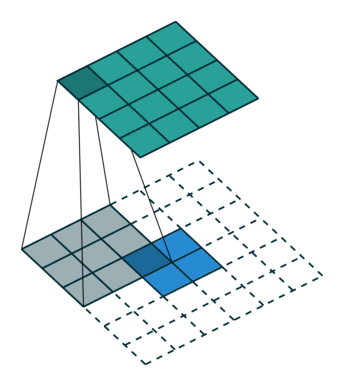<br>
    <sub>transpose of<br>padding = 0, stride = 1</sub>
  </td>
  <td align="center" style="padding:8px">
    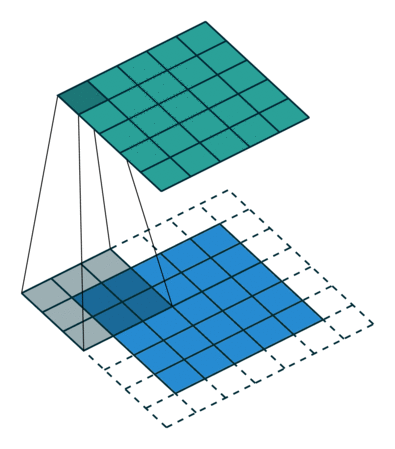<br>
    <sub>transpose of<br>padding = 1, stride = 1</sub>
  </td>
</tr>
<tr>
  <td align="center" style="padding:8px">
    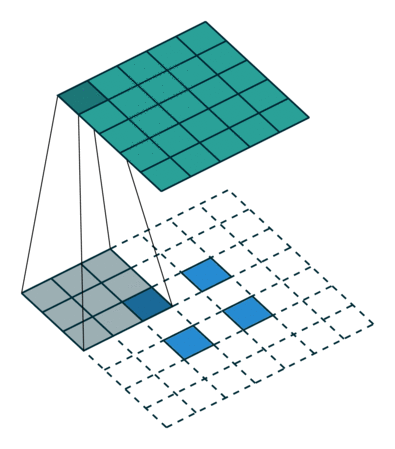<br>
    <sub>transpose of<br>padding = 0, stride = 2</sub>
  </td>
  <td align="center" style="padding:8px">
    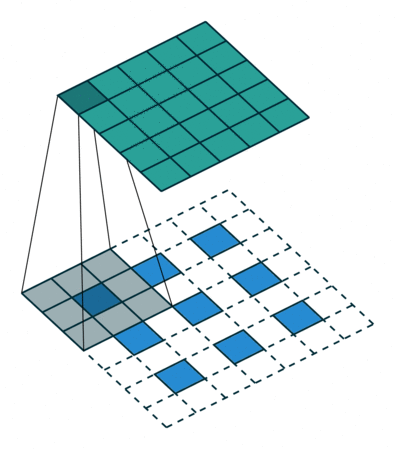<br>
    <sub>transpose of<br>padding = 1, stride = 2</sub>
  </td>
</tr>
</table>

<sub>Animations from V. Dumoulin & F. Visin, <a href="https://github.com/vdumoulin/conv_arithmetic">"A guide to convolution arithmetic for deep learning"</a> (2016).</sub>


### Property: $\operatorname{ConvT2d}_{W,0}\big|_{\mathbb{R}^{C_1\times H\times W}}$ is linear and $\operatorname{ConvT2d}_{W,b}\big|_{\mathbb{R}^{C_1\times H\times W}}$ is affine


Proof: On the finite domain,
$$
\operatorname{ConvT2d}_{W,b}\big|_{\mathbb{R}^{C_1\times H\times W}} = \operatorname{Crop}^{(*,H',W')}\circ\,T^{C_2}_{(p_1,p_2)}\circ\big(\operatorname{InfConvT2d}_{W,b}\big|_{\mathbb{R}^{C_1\times H\times W}}\big).
$$
The claim follows because a composition of linear maps is linear (and adding the constant bias makes it affine):
* $\operatorname{Crop}^{(*,H',W')}$ is linear;
* $T^{C_2}_{(p_1,p_2)}$ is linear (a coordinate relabelling);
* $\operatorname{InfConvT2d}_{W,0}$ is linear and $\operatorname{InfConvT2d}_{W,b}$ is affine.


#### Definition: Output padding operation

The output padding operation appends $o_1$ zero rows and $o_2$ zero columns to the bottom-right of a finite tensor:
$$
\begin{align*}
\operatorname{OutPad}^{(o_1,o_2)}: \mathbb{R}^{C\times H\times W}&\longmapsto \mathbb{R}^{C\times (H+o_1)\times (W+o_2)},\\
\operatorname{OutPad}^{(o_1,o_2)}(X)&=Y,
\end{align*}
$$
where
$$
Y_{i,j,k}=\begin{cases} X_{i,j,k}, & 1\le j\le H,\ 1\le k\le W,\\ 0, & \text{otherwise.}\end{cases}
$$

A stride $s_1>1$ makes convolution many-to-one on sizes: the inputs $H$ and $H+1,\dots,H+s_1-1$ can all map to the same output size $H'$. Choosing $o_1\in\{0,\dots,s_1-1\}$ selects which of those inverse sizes the transposed convolution reproduces. Folding $\operatorname{OutPad}$ into the crop window recovers the size formula $H'=(H-1)s_1-2p_1+h+o_1$.


## Code: $\operatorname{ConvT2d}_{W,b}$

$\operatorname{InfConvT2d}_{W,b}$ needs infinite inputs, so it is only theoretical; the module implements the finite $\operatorname{ConvT2d}_{W,b}$ (PyTorch's `ConvTranspose2d`).


In [ ]:
import torch
import torch.nn as nn

import models.deep_learning.architectures.convolution.conv_transpose2d as mynn


## Testing


In [2]:
in_channels = 2
out_channels = 3
kernel_size = 3
stride = 2
padding = 1
output_padding = 1

batch_size = 1


In [3]:
torch.manual_seed(0)
nn_convt = nn.ConvTranspose2d(
    in_channels, out_channels, kernel_size, stride, padding, output_padding
)
torch.manual_seed(0)
convt = mynn.ConvTranspose2d(
    in_channels, out_channels, kernel_size, stride, padding, output_padding
)


## Weights

The kernel has the transposed channel order `(in_channels, out_channels, h, w)` and the bias has shape `(out_channels,)`.


In [4]:
for name, param in nn_convt.named_parameters():
    print("nn  ", name, tuple(param.shape))
for name, param in convt.named_parameters():
    print("mine", name, tuple(param.shape))


nn   weight (2, 3, 3, 3)
nn   bias (3,)
mine weight (2, 3, 3, 3)
mine bias (3,)


### Output


In [7]:
x = torch.randn(batch_size, in_channels, 4, 4)
nn_out = nn_convt(x)
out = convt(x)
print(f"{nn_out.shape=}")
print(f"{nn_out=}")
print(f"{out.shape=}")
print(f"{out=}")
print("allclose:", torch.allclose(nn_out, out, atol=1e-6))


nn_out.shape=torch.Size([1, 3, 8, 8])
nn_out=tensor([[[[ 0.4158, -0.2035, -0.1300,  0.4054,  0.0437,  0.2667,  0.1824,
            0.0912],
          [-0.4699,  0.2369,  0.2422,  0.3282,  0.1282,  0.2861,  0.1784,
            0.2514],
          [ 0.4363,  0.0841,  0.3293, -0.2529,  0.2585,  0.1873, -0.0912,
            0.2957],
          [-0.2551, -0.0399, -0.1832, -0.3983,  0.1554,  0.2513,  0.5699,
            0.3255],
          [-0.1019, -0.0507,  0.2582, -0.0234,  0.1028,  0.1300, -0.2096,
            0.3792],
          [ 0.3901,  0.1888,  0.2531, -0.2711,  0.0270,  0.3368,  0.4859,
            0.4271],
          [ 0.0312,  0.2513,  0.0281,  0.2380,  0.2998,  0.0284,  0.1289,
            0.1297],
          [ 0.3425,  0.1498,  0.2059,  0.1798, -0.0672,  0.0114,  0.1160,
            0.1430]],

         [[-0.0945, -0.6179, -0.2936, -0.1328, -0.0842,  0.0802, -0.0422,
           -0.0769],
          [-0.1625, -0.3547,  0.3369,  0.1683,  0.1247,  0.1574, -0.3932,
           -0.3013],
   

## Verifying the Adjoint Relationship

We check $\langle \operatorname{Conv2d}(X), Y\rangle = \langle X, \operatorname{ConvT2d}(Y)\rangle$ numerically. With $\operatorname{Conv2d}:C_1\to C_2$ (weight shape $(C_2,C_1,h,w)$) and $\operatorname{ConvT2d}:C_2\to C_1$ sharing that same weight tensor, the two operators are exact transposes when the output padding is chosen so that the spatial sizes pair up. For $H=W=5$, $k=3$, $s=2$, $p=1$ the convolution output is $3\times 3$ and `output_padding=0` sends it back to $5\times 5$.


In [6]:
import models.deep_learning.architectures.convolution.conv2d as convnn

C1, C2 = 2, 3
H = Wsp = 5
k, s, p = 3, 2, 1

torch.manual_seed(0)
conv = convnn.Conv2d(C1, C2, k, stride=s, padding=p, bias=False)
# output_padding=0 inverts the spatial size for H=W=5, k=3, s=2, p=1
convT = mynn.ConvTranspose2d(C2, C1, k, stride=s, padding=p, output_padding=0, bias=False)

# share the same kernel: both have shape (C2, C1, k, k)
convT.weight.data = conv.weight.data.clone()

X = torch.randn(1, C1, H, Wsp)
Y = torch.randn(1, C2, *conv(X).shape[-2:])

lhs = (conv(X) * Y).sum()  # <Conv(X), Y>
rhs = (X * convT(Y)).sum()  # <X, ConvT(Y)>
print(f"lhs = {lhs.item():.6f}")
print(f"rhs = {rhs.item():.6f}")
print("adjoint holds:", torch.allclose(lhs, rhs, atol=1e-5))


lhs = 1.045097
rhs = 1.045097
adjoint holds: True
